In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.colors import ListedColormap5
import ast
import numpy as np
import os
import subprocess
import time
import plotly.express as px
from utils import *

%matplotlib inline

In [55]:
# Constants
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

COLLOR_PALLET = {
            'Other human': '#2986cc', # BLUE
            'Electro-mechanical': '#cc0000', # RED
            'Voice': '#6aa84f', #  green 6aa84f
            'Motorised transport': '#ffa500', # orange
            'Geonature': '#8e7cc3', # PURPLE
            'Animal': '#9b5f00', # BROWN
            'Music': '#d172a4', # PINK
            'Background': '#000000', # BLACK
            'Other Sounds': '#c9d631', # yellow
            'Social/communal': '#d8cbf8', # Light purple
            'Human movement': '#40b674', # light green 40b674
        }

def extract_location(file_path):
    file_name = os.path.basename(file_path)
    # print(f"File name: {file_name}")
    # Split the file name by the underscore
    file_name = file_name.split("_")[2]
    # print(f"File name after split: {file_name}")
    return file_name

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def change_label(classes_list, label, new_label):
    return [new_label if x == label else x for x in classes_list]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": " Lunes",
        "Tuesday": " Martes",
        "Wednesday": " Miércoles",
        "Thursday": " Jueves",
        "Friday": " Viernes",
        "Saturday": " Sábado",
        "Sunday": " Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + df["weekday"]
    return df

def output_dir(path: str):
    # get the abs path and remove the last element
    path = os.path.abspath(path).split("\\")[:-2]
    path = "/".join(path)
    
    visualization_dir = path + "/Visualizations"
    os.makedirs(visualization_dir, exist_ok=True)
    
    return visualization_dir

# get the last git tag version
def list_git_tags():
    try:
        tags = tags = subprocess.check_output(["git", "tag"]).strip().decode()
        return tags.split('\n')
    except subprocess.CalledProcessError:
        return None
    
def select_tag(tags):
    for i, tag in enumerate(tags):
        print(f"{i}: {tag}")
    choice = int(input("Select the tag to use: "))
    tag_selected = tags[choice]
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
        
    return tag_selected

def get_stable_version():
    tags = list_git_tags()
    # get the latest stable version
    tag_selected = tags[-1]
    print(f"Latest stable version: {tag_selected}")
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
    
    print(f"Latest stable version: {tag_selected}")
    
    return tag_selected

print(get_stable_version())
stable_version = get_stable_version()

Latest stable version: v1.1
Latest stable version: v1_1
v1_1
Latest stable version: v1.1
Latest stable version: v1_1


In [56]:
yamnet_classes_path = r"C:\Users\scjaa\Documents\GitHubRepos\AAC\AI_Model\Urban_Model\yamnet_class_map.csv"
yamnet_classes_df = pd.read_csv(yamnet_classes_path)
yamnet_classes = yamnet_classes_df['display_name'].unique()

csv_pred_path = input("Enter the path to the csv file: ")

# clean the csv_pred_path from " and "
csv_pred_path = csv_pred_path.replace('"', '')

# make visualization directory
visualization_dir = output_dir(csv_pred_path)

# get the csv
df = pd.read_csv(csv_pred_path, converters={'class': eval})

# get the location
title = extract_location(csv_pred_path)

# remove nan
df = df.dropna()
df['date'] = pd.to_datetime(df['date'])
# sort by date
df = df.sort_values(by='date')

df

,filename,date,class,probability
0,20231207_021525.WAV,2023-12-07 02:15:25,"[Speech, Television, Inside, small room]","['0.3277', '0.0348', '0.0311']"
1,20231207_051625.WAV,2023-12-07 05:16:25,"[Speech, Narration, monologue, Inside, large r...","['0.7837', '0.0583', '0.0152']"
2,20231207_073210.WAV,2023-12-07 07:32:10,"[Vehicle, Inside, small room, Speech]","['0.1503', '0.0810', '0.0535']"
3,20231207_140420.WAV,2023-12-07 14:04:20,"[Speech, Vehicle, Motor vehicle (road)]","['0.2025', '0.1200', '0.0362']"
4,20231207_213650.WAV,2023-12-07 21:36:50,"[Speech, Narration, monologue, Inside, large r...","['0.6463', '0.0340', '0.0251']"
5,20231208_074715.WAV,2023-12-08 07:47:15,"[Inside, small room, Vehicle, White noise]","['0.1203', '0.0858', '0.0491']"
6,20231208_123350.WAV,2023-12-08 12:33:50,"[Speech, Vehicle, Inside, small room]","['0.1743', '0.0956', '0.0375']"
7,20231209_162005.WAV,2023-12-09 16:20:05,"[Inside, small room, Speech, Vehicle]","['0.1344', '0.0815', '0.0786']"
8,20231210_034555.WAV,2023-12-10 03:45:55,"[Silence, Inside, small room, Rustle]","['0.5601', '0.1303', '0.0213']"
9,20231210_061645.WAV,2023-12-10 06:16:45,"[Inside, small room, Silence, Animal]","['0.1480', '0.1119', '0.0633']"


In [57]:
# df['date'] = pd.to_datetime(df['date'])
time_difference_seconds = df['date'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
print(f"Average interval between each audio file: {average_interval} seconds")
interval_printing(average_interval)

Average interval between each audio file: 30408.88888888889 seconds


In [58]:
df.set_index('date',inplace=True)
df = df.explode('class')
df['display_name'] = df['class']
df['number'] = 1

df_exploded = insert_dates(df)
urban_taxonomy_map = pd.read_json("urban_taxonomy_map_v1_0.json", typ='series').to_dict()
df_exploded['mapped_class'] = df_exploded['class'].map(urban_taxonomy_map)

In [59]:
df_exploded = insert_dates(df)

urban_taxonomy_map = pd.read_json("urban_taxonomy_map_v1_0.json", typ='series').to_dict()
df_exploded['mapped_class'] = df_exploded['class'].map(urban_taxonomy_map)
df_exploded

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class
date,,,,,,,,,,,,,,
2023-12-07 02:15:25,20231207_021525.WAV,Speech,"['0.3277', '0.0348', '0.0311']",Speech,1,2023,12,07,2,15,25,Jueves,07 Jueves,Voice
2023-12-07 02:15:25,20231207_021525.WAV,Television,"['0.3277', '0.0348', '0.0311']",Television,1,2023,12,07,2,15,25,Jueves,07 Jueves,Social/communal
2023-12-07 02:15:25,20231207_021525.WAV,"Inside, small room","['0.3277', '0.0348', '0.0311']","Inside, small room",1,2023,12,07,2,15,25,Jueves,07 Jueves,Background
2023-12-07 05:16:25,20231207_051625.WAV,Speech,"['0.7837', '0.0583', '0.0152']",Speech,1,2023,12,07,5,16,25,Jueves,07 Jueves,Voice
2023-12-07 05:16:25,20231207_051625.WAV,"Narration, monologue","['0.7837', '0.0583', '0.0152']","Narration, monologue",1,2023,12,07,5,16,25,Jueves,07 Jueves,Voice
2023-12-07 05:16:25,20231207_051625.WAV,"Inside, large room or hall","['0.7837', '0.0583', '0.0152']","Inside, large room or hall",1,2023,12,07,5,16,25,Jueves,07 Jueves,Background
2023-12-07 07:32:10,20231207_073210.WAV,Vehicle,"['0.1503', '0.0810', '0.0535']",Vehicle,1,2023,12,07,7,32,10,Jueves,07 Jueves,Motorised transport
2023-12-07 07:32:10,20231207_073210.WAV,"Inside, small room","['0.1503', '0.0810', '0.0535']","Inside, small room",1,2023,12,07,7,32,10,Jueves,07 Jueves,Background
2023-12-07 07:32:10,20231207_073210.WAV,Speech,"['0.1503', '0.0810', '0.0535']",Speech,1,2023,12,07,7,32,10,Jueves,07 Jueves,Voice


In [60]:
# convert string to list
# df['class'] = df['class'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['class'])}")
print(f"Type of the first element: \t\t {type(df['class'][0])}")

# remove labels
# df['class'] = df['class'].apply(lambda x: remove_label(x, 'Nature'))
# df['class'] = df['class'].apply(lambda x: remove_label(x, 'Animal'))

# change labels
# df['class'] = df['class'].apply(lambda x: change_label(x, 'Animal', 'Other Sounds'))
# df['class'] = df['class'].apply(lambda x: change_label(x, 'Other human', 'Other Sounds'))

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'str'>


C:\Users\scjaa\AppData\Local\Temp\ipykernel_1996\2125061872.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Type of the first element: \t\t {type(df['class'][0])}")


In [61]:
print(f"These are the class count:\n\n{df_exploded['class'].value_counts()}")
print(f"\nThese are the class summed: \t\t {df_exploded['class'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df_exploded)}")

These are the class count:

class
Speech                        7
Inside, small room            7
Vehicle                       5
Narration, monologue          2
Inside, large room or hall    2
Silence                       2
Television                    1
Motor vehicle (road)          1
White noise                   1
Rustle                        1
Animal                        1
Name: count, dtype: int64

These are the class summed: 		 30
This is the lenght of the dataframe 	 30


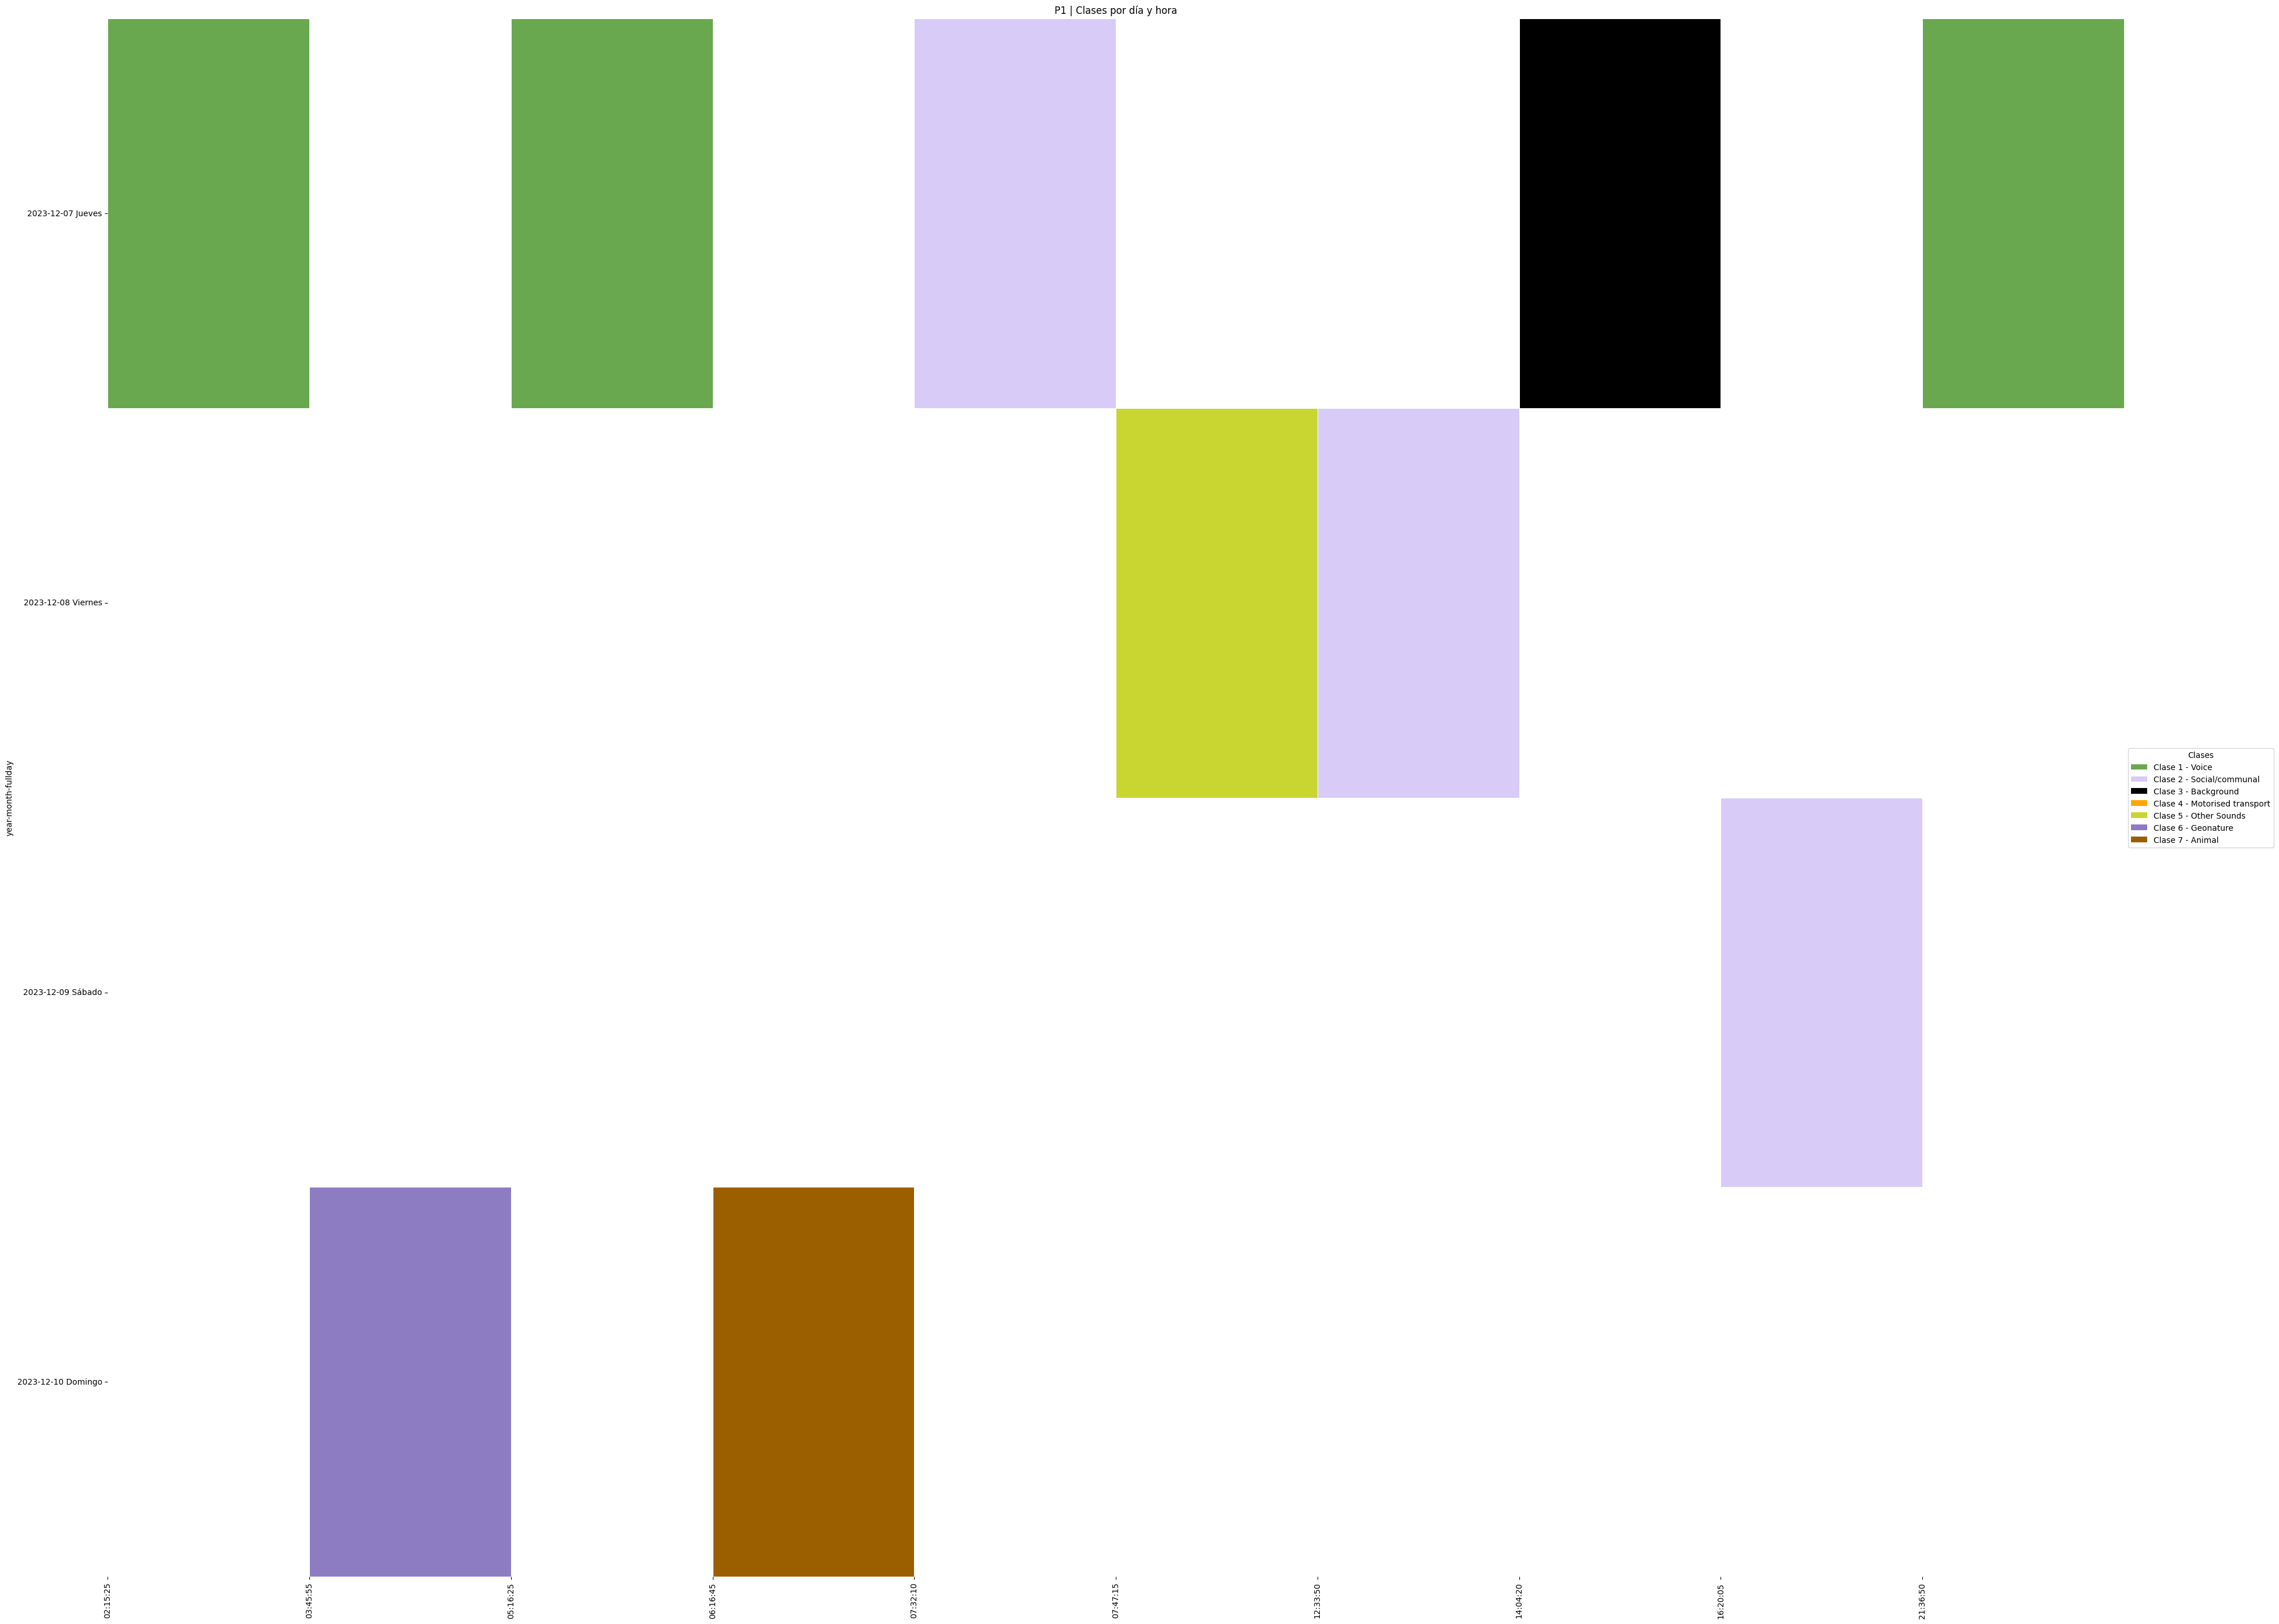

In [62]:
df_exploded = df_exploded.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_exploded['mapped_class'].unique())}
df_exploded['class_num'] = df_exploded['mapped_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_exploded, columns=df_exploded.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    # plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    # print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

# Stack Bar Plotting

In [63]:
df_explode = df.explode('classes_original')
df_explode

KeyError: 'classes_original'

In [64]:
df_exploded

,filename,class,probability,display_name,number,year,month,day,hour,minute,second,weekday,fullday,mapped_class,class_num
date,,,,,,,,,,,,,,,
2023-12-07 02:15:25,20231207_021525.WAV,Speech,"['0.3277', '0.0348', '0.0311']",Speech,1,2023,12,07,2,15,25,Jueves,07 Jueves,Voice,1
2023-12-07 02:15:25,20231207_021525.WAV,Television,"['0.3277', '0.0348', '0.0311']",Television,1,2023,12,07,2,15,25,Jueves,07 Jueves,Social/communal,2
2023-12-07 02:15:25,20231207_021525.WAV,"Inside, small room","['0.3277', '0.0348', '0.0311']","Inside, small room",1,2023,12,07,2,15,25,Jueves,07 Jueves,Background,3
2023-12-07 05:16:25,20231207_051625.WAV,Speech,"['0.7837', '0.0583', '0.0152']",Speech,1,2023,12,07,5,16,25,Jueves,07 Jueves,Voice,1
2023-12-07 05:16:25,20231207_051625.WAV,"Narration, monologue","['0.7837', '0.0583', '0.0152']","Narration, monologue",1,2023,12,07,5,16,25,Jueves,07 Jueves,Voice,1
2023-12-07 05:16:25,20231207_051625.WAV,"Inside, large room or hall","['0.7837', '0.0583', '0.0152']","Inside, large room or hall",1,2023,12,07,5,16,25,Jueves,07 Jueves,Background,3
2023-12-07 07:32:10,20231207_073210.WAV,Vehicle,"['0.1503', '0.0810', '0.0535']",Vehicle,1,2023,12,07,7,32,10,Jueves,07 Jueves,Motorised transport,4
2023-12-07 07:32:10,20231207_073210.WAV,"Inside, small room","['0.1503', '0.0810', '0.0535']","Inside, small room",1,2023,12,07,7,32,10,Jueves,07 Jueves,Background,3
2023-12-07 07:32:10,20231207_073210.WAV,Speech,"['0.1503', '0.0810', '0.0535']",Speech,1,2023,12,07,7,32,10,Jueves,07 Jueves,Voice,1


In [65]:
df_exploded['display_name'] = df_exploded['class']

# read ontology union file
union = pd.read_csv(r"C:\Users\scjaa\AAC - CENTRO DE ACUSTICA APLICADA, S.L\I + D + i - Documentos\Modelos_IA\AAC_IA_Urbano\Taxonomia\yamnet_class_AAC_301123.csv",sep=';')

# merge classes with ontology
df_exploded = df_exploded.merge(
    union,
    how='left',
    on='display_name'
    )


# remove Unnamed columns
df_exploded = df_exploded.loc[:, ~df_exploded.columns.str.contains('^Unnamed')]
df_exploded

,filename,class,probability,display_name,number,year,month,day,hour,minute,...,weekday,fullday,mapped_class,class_num,index,mid,iso_taxonomy,Brown_Level_1,Brown_Level_2,Brown_Level_3
0,20231207_021525.WAV,Speech,"['0.3277', '0.0348', '0.0311']",Speech,1,2023,12,07,2,15,...,Jueves,07 Jueves,Voice,1,0,/m/09x0r,Voice,NaN,Voice,speech
1,20231207_021525.WAV,Television,"['0.3277', '0.0348', '0.0311']",Television,1,2023,12,07,2,15,...,Jueves,07 Jueves,Social/communal,2,518,/m/07c52,Background,NaN,Social/communal,domestic
2,20231207_021525.WAV,"Inside, small room","['0.3277', '0.0348', '0.0311']","Inside, small room",1,2023,12,07,2,15,...,Jueves,07 Jueves,Background,3,500,/t/dd00125,Background,NaN,Background,Background people
3,20231207_051625.WAV,Speech,"['0.7837', '0.0583', '0.0152']",Speech,1,2023,12,07,5,16,...,Jueves,07 Jueves,Voice,1,0,/m/09x0r,Voice,NaN,Voice,speech
4,20231207_051625.WAV,"Narration, monologue","['0.7837', '0.0583', '0.0152']","Narration, monologue",1,2023,12,07,5,16,...,Jueves,07 Jueves,Voice,1,3,/m/02qldy,Voice,NaN,Voice,speech
5,20231207_051625.WAV,"Inside, large room or hall","['0.7837', '0.0583', '0.0152']","Inside, large room or hall",1,2023,12,07,5,16,...,Jueves,07 Jueves,Background,3,501,/t/dd00126,Background,NaN,Background,Background people
6,20231207_073210.WAV,Vehicle,"['0.1503', '0.0810', '0.0535']",Vehicle,1,2023,12,07,7,32,...,Jueves,07 Jueves,Motorised transport,4,294,/m/07yv9,Roadway traffic,NaN,Motorised transport,roadway traffic
7,20231207_073210.WAV,"Inside, small room","['0.1503', '0.0810', '0.0535']","Inside, small room",1,2023,12,07,7,32,...,Jueves,07 Jueves,Background,3,500,/t/dd00125,Background,NaN,Background,Background people
8,20231207_073210.WAV,Speech,"['0.1503', '0.0810', '0.0535']",Speech,1,2023,12,07,7,32,...,Jueves,07 Jueves,Voice,1,0,/m/09x0r,Voice,NaN,Voice,speech
9,20231207_140420.WAV,Speech,"['0.2025', '0.1200', '0.0362']",Speech,1,2023,12,07,14,4,...,Jueves,07 Jueves,Voice,1,0,/m/09x0r,Voice,NaN,Voice,speech


In [68]:
# rename columns
df_exploded.rename(columns={"fullday": "Día", "hour": "Hora", "mid": "Distribución de clases"}, inplace=True)
unique_día_weekday = df_exploded['Día'].unique()

df_exploded['Día'] = pd.Categorical(df_exploded['Día'], categories=unique_día_weekday, ordered=True)
df_exploded.columns

Index(['filename', 'class', 'probability', 'display_name', 'number', 'year',
       'month', 'day', 'Hora', 'minute', 'second', 'weekday', 'Día',
       'mapped_class', 'class_num', 'index', 'Distribución de clases',
       'iso_taxonomy', 'Brown_Level_1', 'Brown_Level_2', 'Brown_Level_3'],
      dtype='object')

In [69]:
dfg = df_exploded.groupby(['Brown_Level_2','Día']).count().reset_index()

fig = px.bar(
    dfg, 
    x='Día',
    y='Distribución de clases',
    color='Brown_Level_2',
    title=f'{title} | Clases por día',
    color_discrete_sequence=px.colors.qualitative.Alphabet, 
    color_discrete_map=COLLOR_PALLET,
    height=900,
    width=2000
)

fig.show()

# save plot
fig.write_image(f"{visualization_dir}/{title}_classes_per_day_{stable_version}.png")
print(f"Image was saved in {visualization_dir}/{title}_classes_per_day_{stable_version}.png")

C:\Users\scjaa\AppData\Local\Temp\ipykernel_1996\3604943692.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df_exploded.groupby(['Brown_Level_2','Día']).count().reset_index()


# 15 minutes resamply

In [ ]:
# resample the df_15 to get one row for each 15 minutes without missing columns
df_15 = df.resample("15T").mean()
# remove class_num column
# df_15.drop(columns=["class_num"], inplace=True)
df_15

,sum_probs_custom,sum_probs_original,year,month,hour,minute,second,class_num
datetime,,,,,,,,
2024-01-22 12:15:00,0.482746,0.400094,2024.0,1.0,12.0,26.500000,20.000000,2.166667
2024-01-22 12:30:00,0.536084,0.430475,2024.0,1.0,12.0,37.000000,20.000000,2.155556
2024-01-22 12:45:00,0.510472,0.419819,2024.0,1.0,12.0,52.000000,20.000000,2.666667
2024-01-22 13:00:00,0.509150,0.484509,2024.0,1.0,13.0,7.000000,20.000000,2.333333
2024-01-22 13:15:00,0.548797,0.388088,2024.0,1.0,13.0,22.000000,20.000000,2.022222
...,...,...,...,...,...,...,...,...
2024-01-27 14:30:00,0.507172,0.358691,2024.0,1.0,14.0,37.000000,24.000000,1.688889
2024-01-27 14:45:00,0.535232,0.384410,2024.0,1.0,14.0,52.000000,24.000000,1.355556
2024-01-27 15:00:00,0.533958,0.421177,2024.0,1.0,15.0,6.891892,25.081081,1.513514


In [ ]:
# Separate numerical and categorical columns
numerical_cols = ['sum_probs_custom', 'sum_probs_original', 'year', 'month', 'hour', 'minute', 'second']
categorical_cols = ['single_class']

# Resample numerical columns
df_numerical = df[numerical_cols].resample('5T').mean()

# Resample categorical columns
df_categorical = df[categorical_cols].resample('5T').agg(lambda x: x.value_counts().index[0] if not x.empty else None)

# Merge the resampled data
df_resampled = pd.concat([df_numerical, df_categorical], axis=1)

# Reapply the mapping to categorical data
class_to_num = {class_name: index + 1 for index, class_name in enumerate(df['single_class'].unique())}
df_resampled['class_num'] = df_resampled['single_class'].map(class_to_num)

# remove nan values
df_resampled = df_resampled.dropna()
df_resampled = insert_dates(df_resampled)
df_resampled

,sum_probs_custom,sum_probs_original,year,month,hour,minute,second,single_class,class_num,day,weekday,fullday
datetime,,,,,,,,,,,,
2024-01-22 12:20:00,0.456313,0.390632,2024,1,12,20,0,Animal,1.0,22,Lunes,22 Lunes
2024-01-22 12:25:00,0.488033,0.401987,2024,1,12,25,0,Motorised transport,2.0,22,Lunes,22 Lunes
2024-01-22 12:30:00,0.511859,0.493730,2024,1,12,30,0,Motorised transport,2.0,22,Lunes,22 Lunes
2024-01-22 12:35:00,0.556183,0.464133,2024,1,12,35,0,Motorised transport,2.0,22,Lunes,22 Lunes
2024-01-22 12:40:00,0.540209,0.333563,2024,1,12,40,0,Motorised transport,2.0,22,Lunes,22 Lunes
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-27 15:20:00,0.579221,0.499496,2024,1,15,20,0,Animal,1.0,27,Sábado,27 Sábado
2024-01-27 15:25:00,0.632560,0.590367,2024,1,15,25,0,Animal,1.0,27,Sábado,27 Sábado
2024-01-27 15:30:00,0.589519,0.498468,2024,1,15,30,0,Animal,1.0,27,Sábado,27 Sábado


Saved image at //192.168.205.117/AAC_Server/INDUSTRIA/23132-IRUÑA_OCA_CANTERA/5-Resultados/FBD3A7-FAA212-P2_CAMPAÑA1/URBAN_Model/Visualizations/FBD3A7-FAA212_predictions_map_v1_0.png


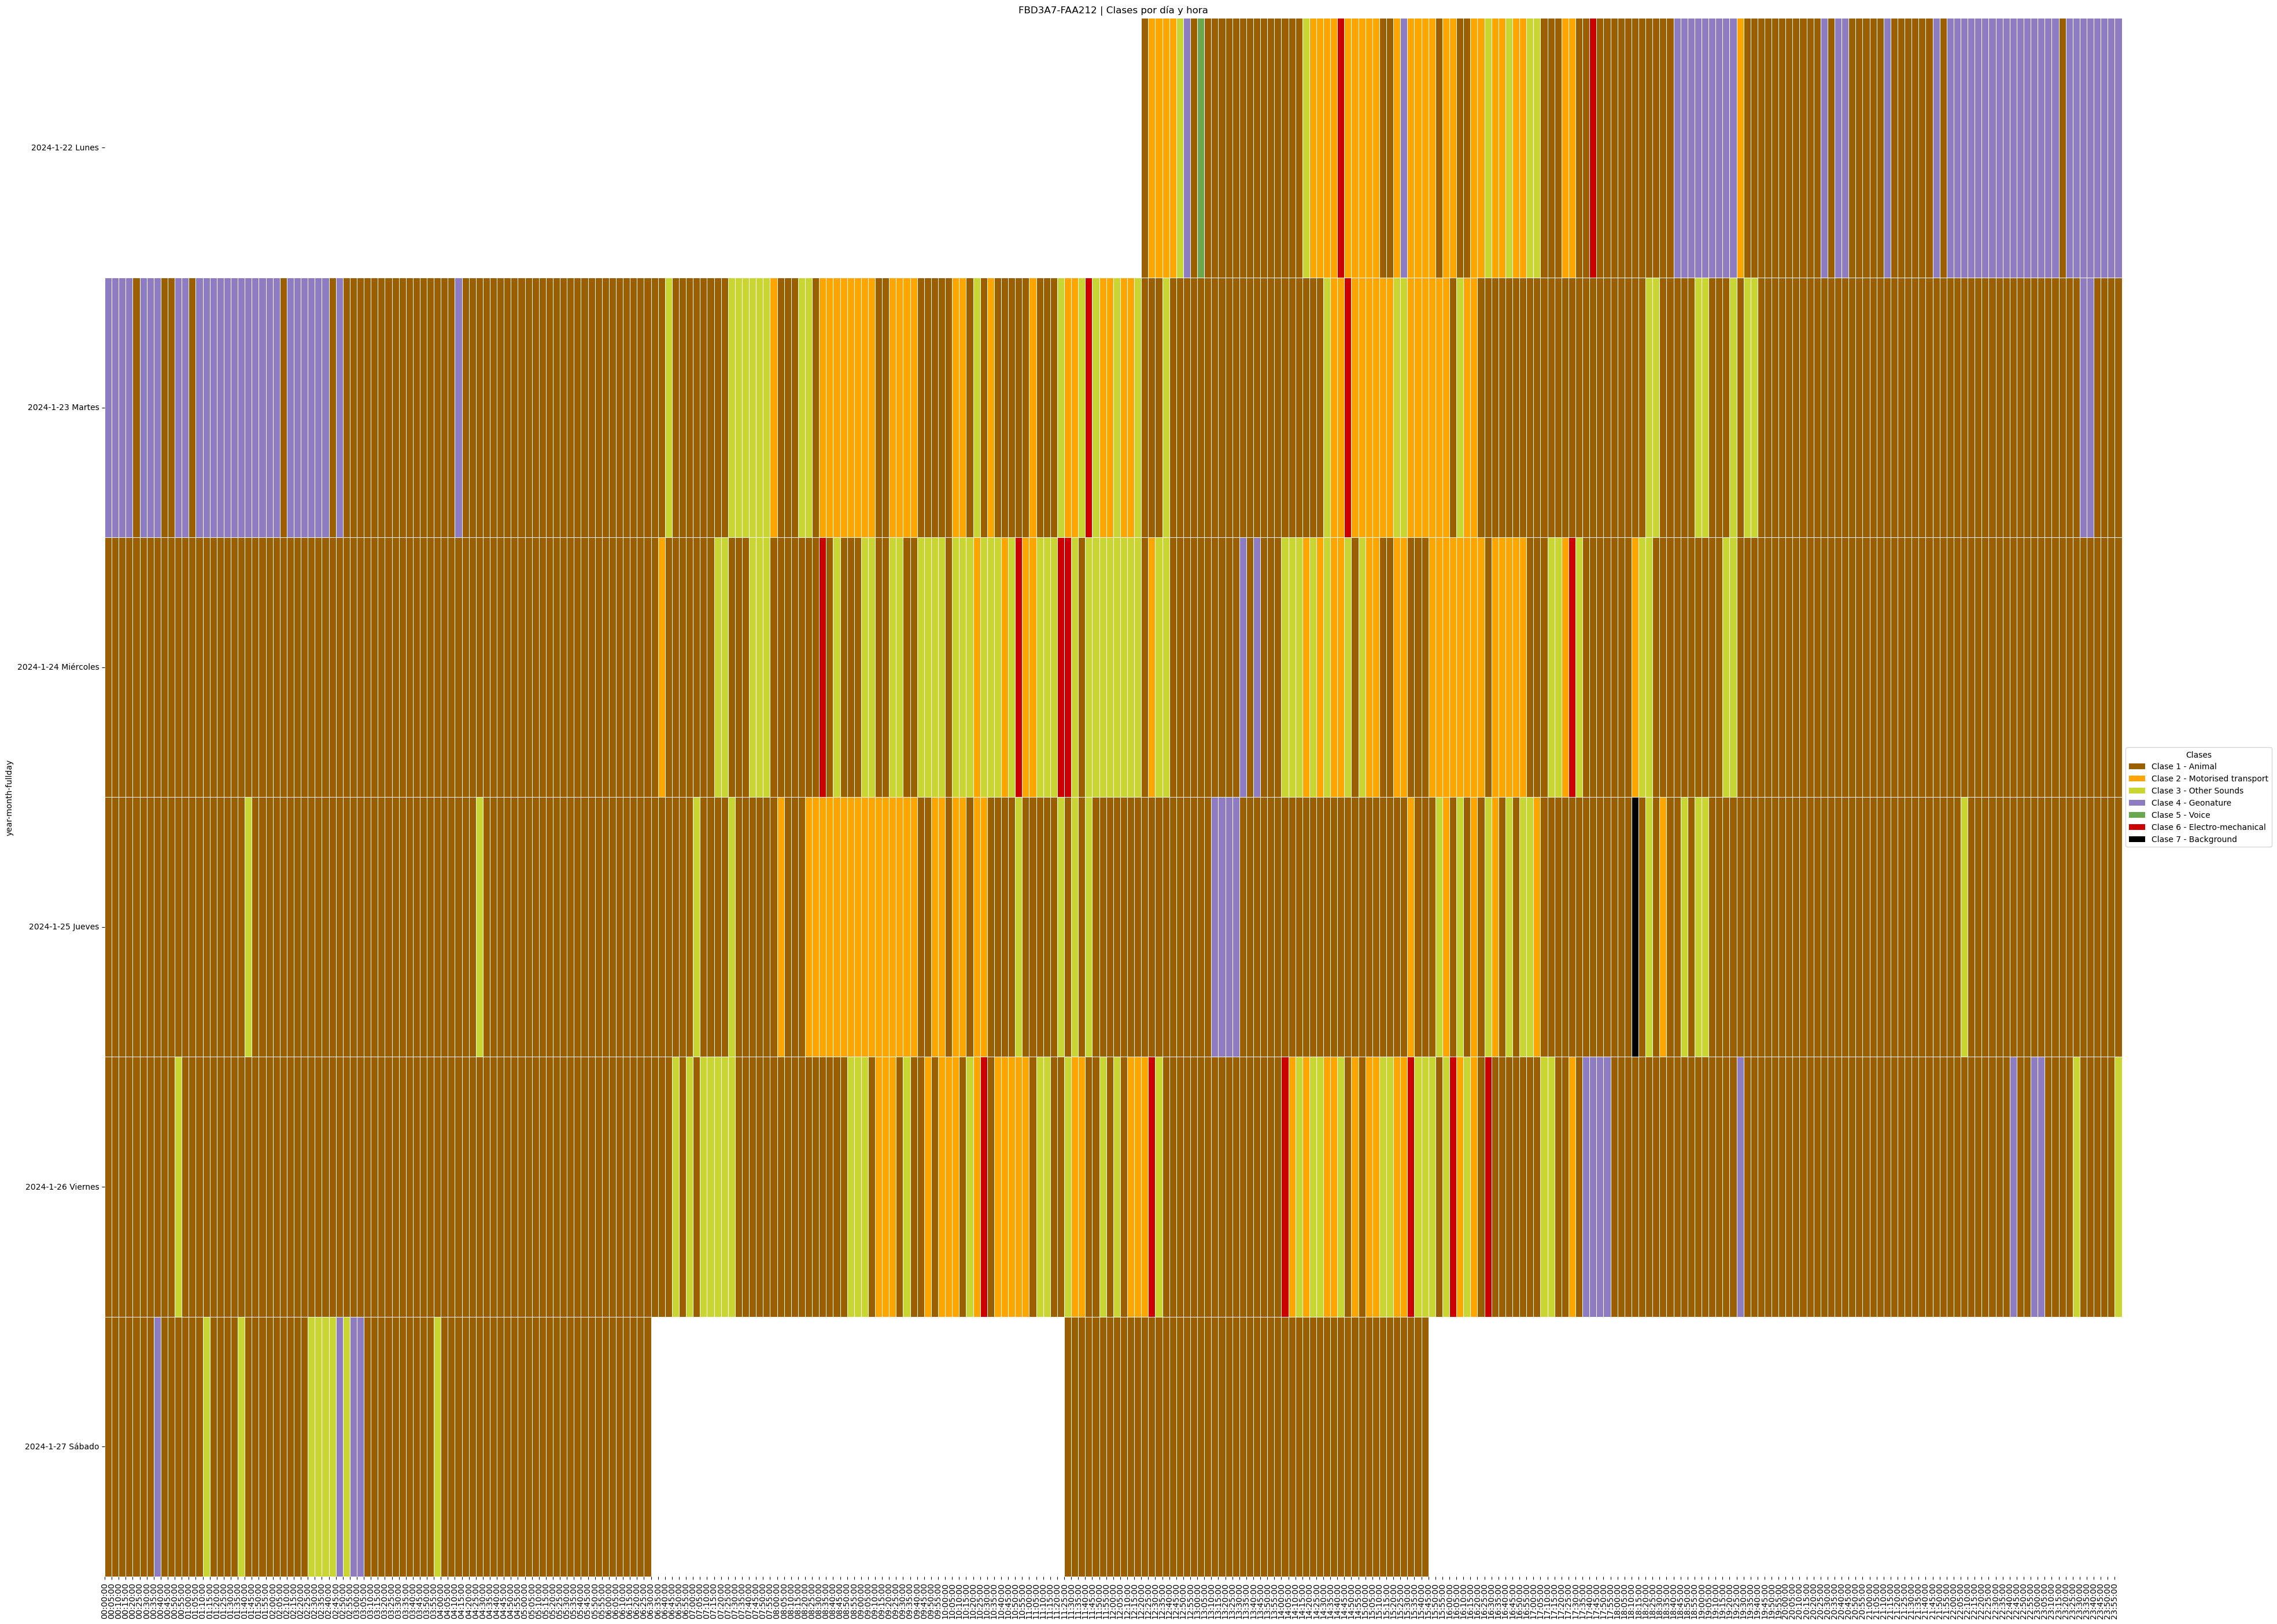

In [ ]:
df_resampled = df_resampled.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_resampled['single_class'].unique())}
df_resampled['class_num'] = df_resampled['single_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_resampled, columns=df_resampled.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

In [ ]:
day = "19"

# filter for the specific day across all years and months
df_xth = df[df["fullday"].str.startswith(day)]

if df_xth.empty:
    print(f"No data for the {day}th day across all years and months. Skipping...")

else:
    plt.figure(figsize=(20, 10))
    
    # pivot is used to get the heatmap | aggfunc is used to get the mode of the classes for each time
    day_class = pd.pivot_table(data=df_xth, columns=df_xth.index.time, index=["year", "month"], values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
    
    if day_class.isna().all().all() or day_class.empty:
        print(f"No valid data for the {day}th day. Skipping...")

    else:
        # unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # setup the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        
        # Hide the y-axis labels (to remove year and month labels)
        ax.yaxis.set_visible(False)
        
        # include the years and months in the dataset
        years = "-".join(map(str, sorted(df_xth["year"].unique())))
        months = "-".join(map(str, sorted(df_xth["month"].unique())))

        # legend
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {years}-{months}-{day}")

        plt.show()

No data for the 19th day across all years and months. Skipping...


In [ ]:
day = "19"

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    for month in sorted(df_year["month"].unique()):
        df_temp = df_year[df_year["month"] == month]
        
        df_xth = df_temp[df_temp["fullday"].str.startswith(day)]
        
        start_time = pd.to_datetime("17:18:00").time()
        end_time = pd.to_datetime("18:04:00").time()
        time_mask = (df_xth.index.time >= start_time) & (df_xth.index.time <= end_time)
        df_xth_filtered = df_xth[time_mask]
        
        if df_xth_filtered.empty:
            print(f"No data for the {day}th day in Year: {year}, Month: {month} within the specified time range. Skipping...")
            continue
        
        plt.figure(figsize=(18, 10))
        
        day_class = pd.pivot_table(data=df_xth_filtered, columns=df_xth_filtered.index.time, index="fullday", values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
        
        if day_class.isna().all().all() or day_class.empty:
            print(f"No valid data for Year: {year}, Month: {month}, Day: {day} within the specified time range. Skipping...")
            continue
        
        # Get unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Create a list of colors in the order of class numbers
        cmap = [num_to_color[int(cls_num)] for cls_num in unique_classes if cls_num in name_class]

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=num_to_color[int(cls_num)], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # Create the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Completely hide the y-axis
        ax.yaxis.set_visible(False)
        
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {year}-{month}-{day} within {start_time.strftime('%H:%M:%S')} to {end_time.strftime('%H:%M:%S')}")

        plt.show()

No data for the 19th day in Year: 2024, Month: 1 within the specified time range. Skipping...
